In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')

In [4]:
df = dataset.build_main()

In [5]:
df.columns

Index(['delivery_start', 'market', 'target', 'global_horizontal_irradiance',
       'diffuse_horizontal_irradiance', 'direct_normal_irradiance',
       'cloud_cover_total', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'precipitation_amount', 'visibility',
       'air_temperature_2m', 'apparent_temperature_2m',
       'dew_point_temperature_2m', 'wet_bulb_temperature_2m',
       'surface_pressure', 'freezing_level_height', 'relative_humidity_2m',
       'convective_available_potential_energy', 'lifted_index',
       'convective_inhibition', 'wind_speed_80m', 'wind_direction_80m',
       'wind_gust_speed_10m', 'wind_speed_10m', 'solar_forecast',
       'wind_forecast', 'load_forecast', 'delivery_end', 'hour', 'dayofweek',
       'month', 'hour_sin', 'hour_cos', 'residual', 'residual_sq',
       'renewable_ratio', 'air_temperature_2m_roll_6_mean',
       'air_temperature_2m_roll_24_std', 'wind_speed_10m_roll_6_mean',
       'wind_speed_10m_roll_24_std', 'residual_roll_

In [6]:
df.head()

,delivery_start,market,target,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,...,hour_cos,residual,residual_sq,renewable_ratio,air_temperature_2m_roll_6_mean,air_temperature_2m_roll_24_std,wind_speed_10m_roll_6_mean,wind_speed_10m_roll_24_std,residual_roll_6_mean,residual_roll_24_std
6,2023-01-01 01:00:00+00:00,Market A,-0.839,0.0,0.0,0.0,15.0,0.0,0.0,15.0,...,0.965926,13492.8898,1.820581e+08,0.639010,12.505500,0.671751,14.632002,0.629437,13802.89990,438.420488
12,2023-01-01 02:00:00+00:00,Market A,-1.107,0.0,0.0,0.0,17.0,0.0,0.0,17.0,...,0.866025,12970.3303,1.682295e+08,0.643035,11.797167,1.315612,13.892494,1.355992,13525.37670,571.982204
18,2023-01-01 03:00:00+00:00,Market A,0.035,0.0,0.0,0.0,16.0,0.0,0.0,16.0,...,0.707107,12507.9595,1.564491e+08,0.646027,11.405500,1.329474,13.040210,2.032575,13271.02240,690.574785
24,2023-01-01 04:00:00+00:00,Market A,-0.829,0.0,0.0,0.0,10.0,0.0,0.0,10.0,...,0.500000,12126.7403,1.470578e+08,0.648220,11.160500,1.275049,12.815792,1.830393,13042.16598,787.112734
30,2023-01-01 05:00:00+00:00,Market A,-0.684,0.0,0.0,0.0,5.0,0.0,0.0,5.0,...,0.258819,11844.6507,1.402958e+08,0.648576,10.988833,1.215490,12.769516,1.641073,12842.58010,857.113940


In [7]:
df.shape

(140250, 44)

In [8]:
df.isna().sum()

delivery_start                           0
market                                   0
target                                   0
global_horizontal_irradiance             0
diffuse_horizontal_irradiance            0
direct_normal_irradiance                 0
cloud_cover_total                        0
cloud_cover_low                          0
cloud_cover_mid                          0
cloud_cover_high                         0
precipitation_amount                     0
visibility                               0
air_temperature_2m                       0
apparent_temperature_2m                  0
dew_point_temperature_2m                 0
wet_bulb_temperature_2m                  0
surface_pressure                         0
freezing_level_height                    0
relative_humidity_2m                     0
convective_available_potential_energy    0
lifted_index                             0
convective_inhibition                    0
wind_speed_80m                           0
wind_direct

In [9]:
time_diffs = df.index.to_series().diff().value_counts()
print(time_diffs)

 6.0         140244
-140243.0         5
Name: count, dtype: int64


In [10]:
print(df.groupby('market')['delivery_start'].diff().value_counts())

delivery_start
0 days 01:00:00    140244
Name: count, dtype: int64


In [11]:
df.index.to_series().describe()

count    140250.000000
mean      70130.500000
std       40486.831964
min           6.000000
25%       35068.250000
50%       70130.500000
75%      105192.750000
max      140255.000000
dtype: float64

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = df[df['market']=='Market A']

In [14]:
df.shape

(23375, 44)

In [15]:
start_date = '2025-01-01'
end_date = '2025-01-03'

# Filter the DataFrame
df_testing = df[(df['delivery_start'] >= start_date) & (df['delivery_start'] <= end_date)]

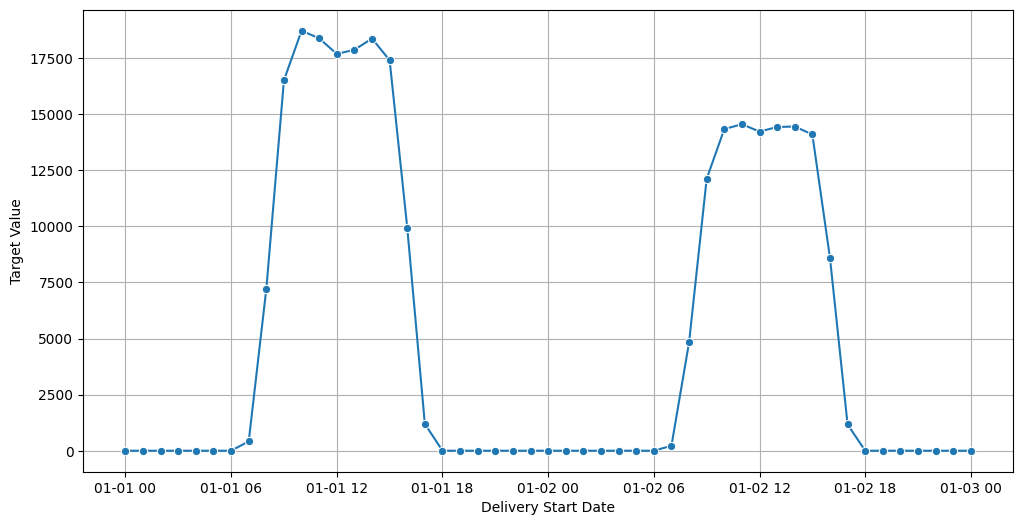

In [16]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_testing, x='delivery_start', y='solar_forecast', marker='o')
plt.xlabel('Delivery Start Date')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

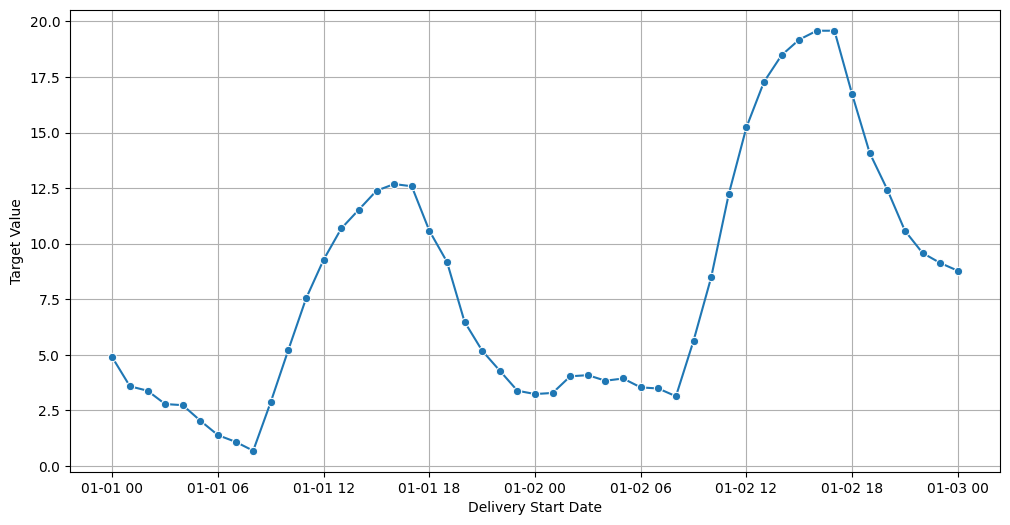

In [17]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_testing, x='delivery_start', y='air_temperature_2m', marker='o')
plt.xlabel('Delivery Start Date')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

In [18]:
start_date = '2025-01-01'
end_date = '2025-01-31'

# Filter the DataFrame
df_filtered = df[(df['delivery_start'] >= start_date) & (df['delivery_start'] <= end_date)]

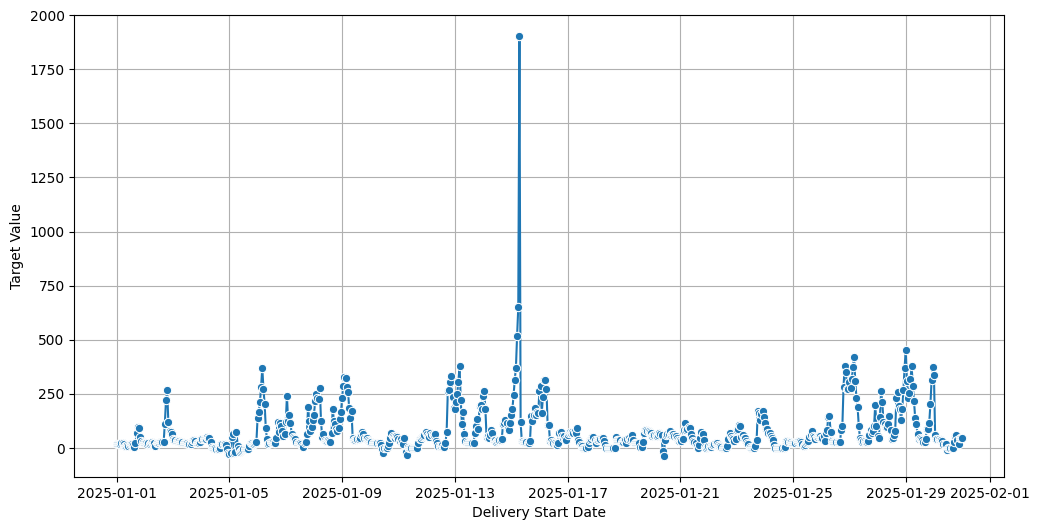

In [19]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_filtered, x='delivery_start', y='target', marker='o')
plt.xlabel('Delivery Start Date')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

In [20]:
start_date = '2025-01-01'
end_date = '2025-01-08'

# Filter the DataFrame
df_filtered = df[(df['delivery_start'] >= start_date) & (df['delivery_start'] <= end_date)]

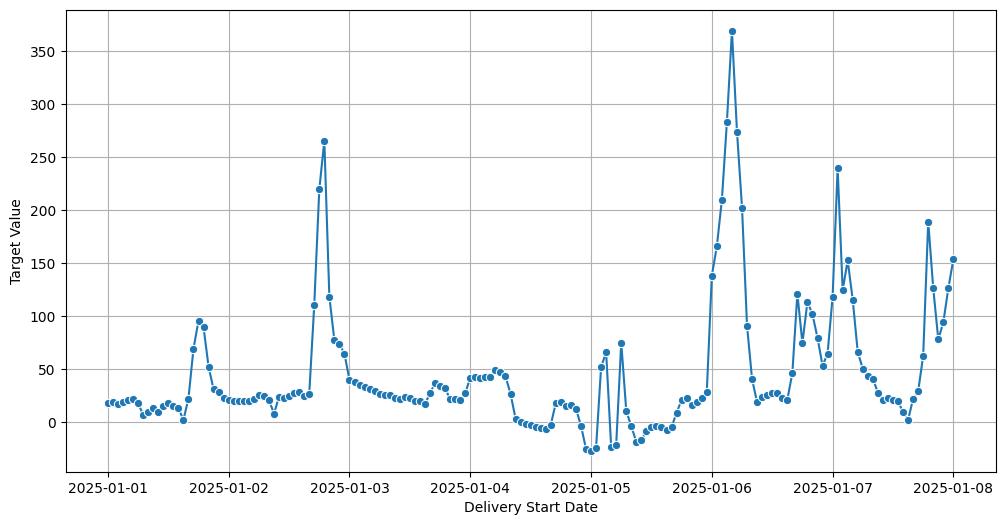

In [21]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_filtered, x='delivery_start', y='target', marker='o')
plt.xlabel('Delivery Start Date')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

In [22]:
start_date = '2025-01-01'
end_date = '2025-01-03'

# Filter the DataFrame
df_filtered = df[(df['delivery_start'] >= start_date) & (df['delivery_start'] <= end_date)]

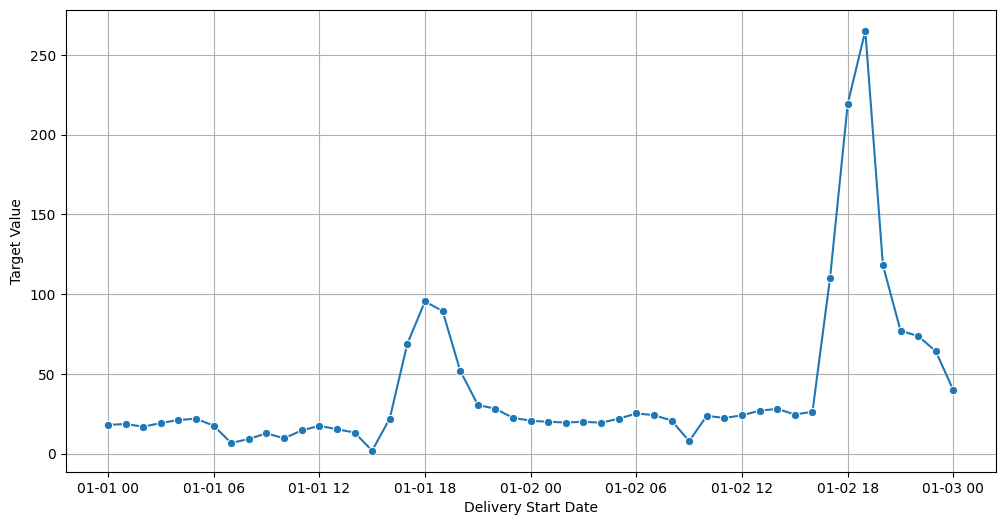

In [23]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_filtered, x='delivery_start', y='target', marker='o')
plt.xlabel('Delivery Start Date')
plt.ylabel('Target Value')
plt.grid(True)
plt.show()

In [24]:
df.columns

Index(['delivery_start', 'market', 'target', 'global_horizontal_irradiance',
       'diffuse_horizontal_irradiance', 'direct_normal_irradiance',
       'cloud_cover_total', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'precipitation_amount', 'visibility',
       'air_temperature_2m', 'apparent_temperature_2m',
       'dew_point_temperature_2m', 'wet_bulb_temperature_2m',
       'surface_pressure', 'freezing_level_height', 'relative_humidity_2m',
       'convective_available_potential_energy', 'lifted_index',
       'convective_inhibition', 'wind_speed_80m', 'wind_direction_80m',
       'wind_gust_speed_10m', 'wind_speed_10m', 'solar_forecast',
       'wind_forecast', 'load_forecast', 'delivery_end', 'hour', 'dayofweek',
       'month', 'hour_sin', 'hour_cos', 'residual', 'residual_sq',
       'renewable_ratio', 'air_temperature_2m_roll_6_mean',
       'air_temperature_2m_roll_24_std', 'wind_speed_10m_roll_6_mean',
       'wind_speed_10m_roll_24_std', 'residual_roll_

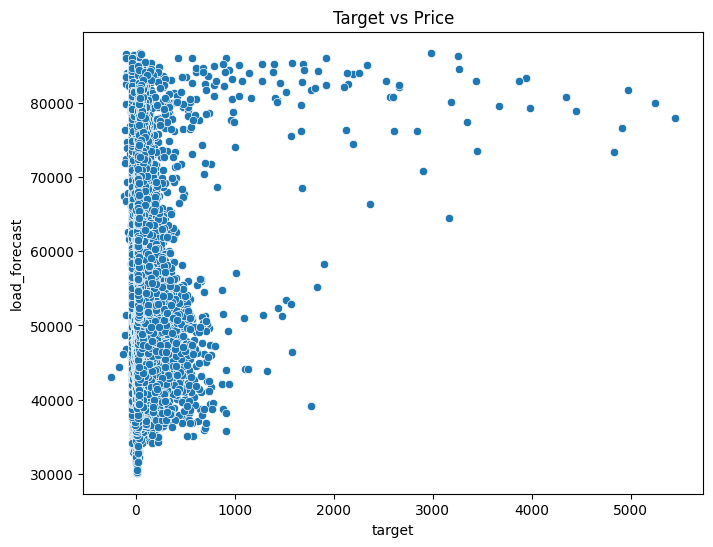

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='target', y='load_forecast')
plt.title('Target vs Price')
plt.show()

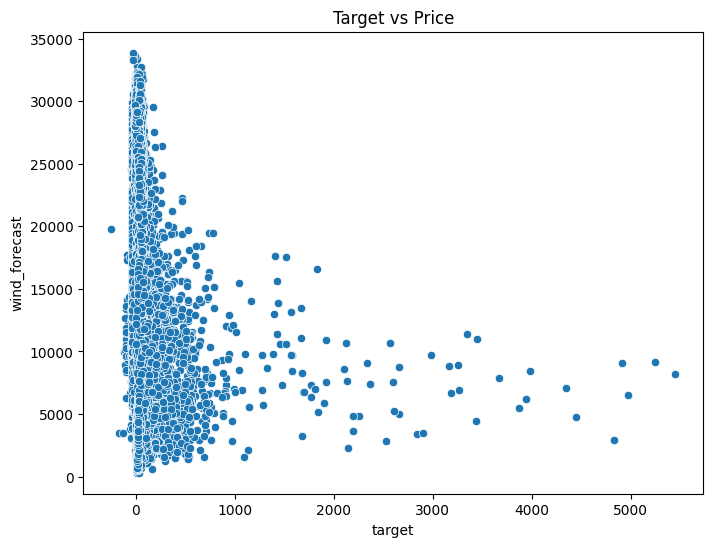

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='target', y='wind_forecast')
plt.title('Target vs Price')
plt.show()

In [27]:
df.columns

Index(['delivery_start', 'market', 'target', 'global_horizontal_irradiance',
       'diffuse_horizontal_irradiance', 'direct_normal_irradiance',
       'cloud_cover_total', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'precipitation_amount', 'visibility',
       'air_temperature_2m', 'apparent_temperature_2m',
       'dew_point_temperature_2m', 'wet_bulb_temperature_2m',
       'surface_pressure', 'freezing_level_height', 'relative_humidity_2m',
       'convective_available_potential_energy', 'lifted_index',
       'convective_inhibition', 'wind_speed_80m', 'wind_direction_80m',
       'wind_gust_speed_10m', 'wind_speed_10m', 'solar_forecast',
       'wind_forecast', 'load_forecast', 'delivery_end', 'hour', 'dayofweek',
       'month', 'hour_sin', 'hour_cos', 'residual', 'residual_sq',
       'renewable_ratio', 'air_temperature_2m_roll_6_mean',
       'air_temperature_2m_roll_24_std', 'wind_speed_10m_roll_6_mean',
       'wind_speed_10m_roll_24_std', 'residual_roll_